In [1]:
# 📦 Installation de MLflow (si pas déjà fait)
!pip install mlflow

import os
import mlflow
import mlflow.pytorch
from mlflow.tracking import MlflowClient

# Configuration MLflow
mlflow.set_tracking_uri("file:./mlruns")
mlflow.set_experiment("HAM10000_CNN_Training")

print(f"✅ MLflow version: {mlflow.__version__}")
print(f"📁 MLflow runs sauvegardés dans: ./mlruns")


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable


C:\Users\jihen\AppData\Roaming\Python\Python314\site-packages\mlflow\tracking\_tracking_service\utils.py:178: FutureWarning: The filesystem tracking backend (e.g., './mlruns') will be deprecated in February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://github.com/mlflow/mlflow/issues/18534 for more details and migration guidance. For migrating existing data, https://github.com/mlflow/mlflow-export-import can be used.
  return FileStore(store_uri, store_uri)
2026/02/12 20:06:02 INFO mlflow.tracking.fluent: Experiment with name 'HAM10000_CNN_Training' does not exist. Creating a new experiment.


✅ MLflow version: 3.9.0
📁 MLflow runs sauvegardés dans: ./mlruns


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import models, transforms
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
import warnings
warnings.filterwarnings('ignore')

# Configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🔥 Device: {device}")

🔥 Device: cpu


In [4]:
import sys
import os
sys.path.append(os.path.abspath(".."))
from advanced_augmentation_simple import BalancedSkinDataset

# Dataset équilibré
dataset = BalancedSkinDataset(
    target_samples=300,
    mode='train',
    data_dir=os.path.join("..", "data")
)

# Split train/val (80/20)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

print(f"✅ Train: {len(train_dataset)} images")
print(f"✅ Validation: {len(val_dataset)} images")

🎯 SOLUTION SIMPLIFIÉE HAM10000 - VRAIES IMAGES

🔧 Création dataset train...
✅ Données chargées: 10015 images
📁 Fichier CSV: c:\Users\jihen\Documents\skin-lesion-detection\data\HAM10000_metadata.csv
📊 Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']

📈 DISTRIBUTION ORIGINALE:
  akiec: 327 images (3.3%)
  bcc: 514 images (5.1%)
  bkl: 1099 images (11.0%)
  df: 115 images (1.1%)
  mel: 1113 images (11.1%)
  nv: 6705 images (66.9%)
  vasc: 142 images (1.4%)

📈 DISTRIBUTION ÉQUILIBRÉE:
  akiec: 300 images (14.3%)
  bcc: 300 images (14.3%)
  bkl: 300 images (14.3%)
  df: 300 images (14.3%)
  mel: 300 images (14.3%)
  nv: 300 images (14.3%)
  vasc: 300 images (14.3%)
📂 Dossier images trouvé: c:\Users\jihen\Documents\skin-lesion-detection\data\images

✅ Dataset créé: 2100 images
✅ Train: 1680 images
✅ Validation: 420 images


In [5]:
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, sampler=None)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

print(f"🚀 Batches par époque: {len(train_loader)}")

🚀 Batches par époque: 53


In [6]:
class SkinLesionModel(nn.Module):
    def __init__(self, num_classes=7, model_name='resnet50'):
        super().__init__()
        
        # Charger ResNet50 pré-entraîné
        if model_name == 'resnet50':
            self.base = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
            in_features = self.base.fc.in_features
            self.base.fc = nn.Identity()
        elif model_name == 'efficientnet':
            self.base = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
            in_features = self.base.classifier[1].in_features
            self.base.classifier = nn.Identity()
        
        # Classificateur personnalisé
        self.classifier = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes)
        )
    
    def forward(self, x):
        features = self.base(x)
        return self.classifier(features)

# Initialisation
model = SkinLesionModel(num_classes=7, model_name='resnet50').to(device)
print(f"✅ Modèle: ResNet50 pré-entraîné")
print(f"📊 Paramètres: {sum(p.numel() for p in model.parameters()):,}")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to C:\Users\jihen/.cache\torch\hub\checkpoints\resnet50-0676ba61.pth


100.0%


✅ Modèle: ResNet50 pré-entraîné
📊 Paramètres: 24,034,375


In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

def train_epoch(model, loader, criterion, optimizer):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    return running_loss / len(loader), 100. * correct / total

def validate(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    return running_loss / len(loader), 100. * correct / total, all_preds, all_labels

In [9]:
num_epochs = 30
best_acc = 0.0

with mlflow.start_run(run_name="ResNet50_HAM10000"):
    
    # Log paramètres
    mlflow.log_param("model", "ResNet50")
    mlflow.log_param("batch_size", batch_size)
    mlflow.log_param("learning_rate", 0.0001)
    mlflow.log_param("epochs", num_epochs)
    mlflow.log_param("optimizer", "Adam")
    mlflow.log_param("dataset_size", len(dataset))
    mlflow.log_param("train_size", len(train_dataset))
    mlflow.log_param("val_size", len(val_dataset))
    
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    for epoch in range(num_epochs):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc, val_preds, val_labels = validate(model, val_loader, criterion)
        
        # Scheduler
        scheduler.step(val_loss)
        
        # Log metrics
        mlflow.log_metric("train_loss", train_loss, step=epoch)
        mlflow.log_metric("train_acc", train_acc, step=epoch)
        mlflow.log_metric("val_loss", val_loss, step=epoch)
        mlflow.log_metric("val_acc", val_acc, step=epoch)
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        print(f"Epoch [{epoch+1}/{num_epochs}] "
              f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}% "
              f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
        
        # Sauvegarde du meilleur modèle
        if val_acc > best_acc:
            best_acc = val_acc
            best_epoch = epoch + 1
            torch.save(model.state_dict(), "best_model_resnet50.pth")
            mlflow.log_artifact("best_model_resnet50.pth")
    
    # Log du modèle final
    mlflow.pytorch.log_model(model, "model_final")
    
    # Log des métriques finales
    mlflow.log_metric("best_val_acc", best_acc)
    mlflow.log_metric("best_epoch", best_epoch)
    
    print(f"\n🎯 Meilleure accuracy validation: {best_acc:.2f}% à l'époque {best_epoch}")

Epoch [1/30] Train Loss: 1.4575, Train Acc: 48.87% Val Loss: 0.9942, Val Acc: 61.19%
Epoch [2/30] Train Loss: 0.9159, Train Acc: 66.96% Val Loss: 0.9256, Val Acc: 65.00%
Epoch [3/30] Train Loss: 0.7374, Train Acc: 72.32% Val Loss: 0.8023, Val Acc: 69.76%
Epoch [4/30] Train Loss: 0.6360, Train Acc: 77.02% Val Loss: 0.8804, Val Acc: 68.33%
Epoch [5/30] Train Loss: 0.6042, Train Acc: 78.33% Val Loss: 0.7496, Val Acc: 71.90%
Epoch [6/30] Train Loss: 0.5386, Train Acc: 80.54% Val Loss: 0.6689, Val Acc: 75.00%
Epoch [7/30] Train Loss: 0.5014, Train Acc: 82.98% Val Loss: 0.7909, Val Acc: 72.86%
Epoch [8/30] Train Loss: 0.4648, Train Acc: 83.10% Val Loss: 0.6852, Val Acc: 72.14%
Epoch [9/30] Train Loss: 0.4056, Train Acc: 84.94% Val Loss: 0.7186, Val Acc: 73.81%
Epoch [10/30] Train Loss: 0.3758, Train Acc: 86.43% Val Loss: 0.6806, Val Acc: 75.71%
Epoch [11/30] Train Loss: 0.3257, Train Acc: 89.17% Val Loss: 0.5878, Val Acc: 81.43%
Epoch [12/30] Train Loss: 0.2423, Train Acc: 91.25% Val Loss: 0

2026/02/12 23:06:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/02/12 23:06:33 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.


Epoch [30/30] Train Loss: 0.0531, Train Acc: 98.57% Val Loss: 0.6720, Val Acc: 80.95%

🎯 Meilleure accuracy validation: 83.57% à l'époque 29


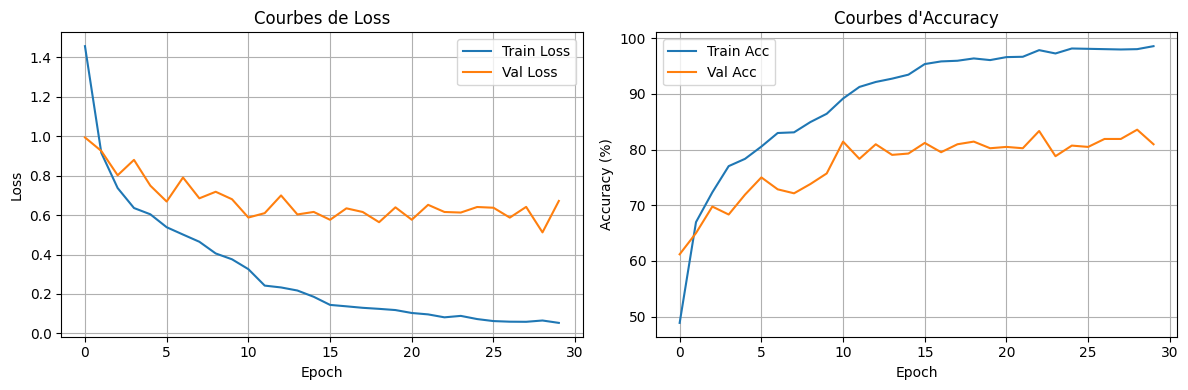

In [10]:
plt.figure(figsize=(12, 4))

# Loss
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Courbes de Loss')
plt.legend()
plt.grid(True)

# Accuracy
plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Courbes d\'Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig('training_curves.png')
mlflow.log_artifact('training_curves.png')
plt.show()

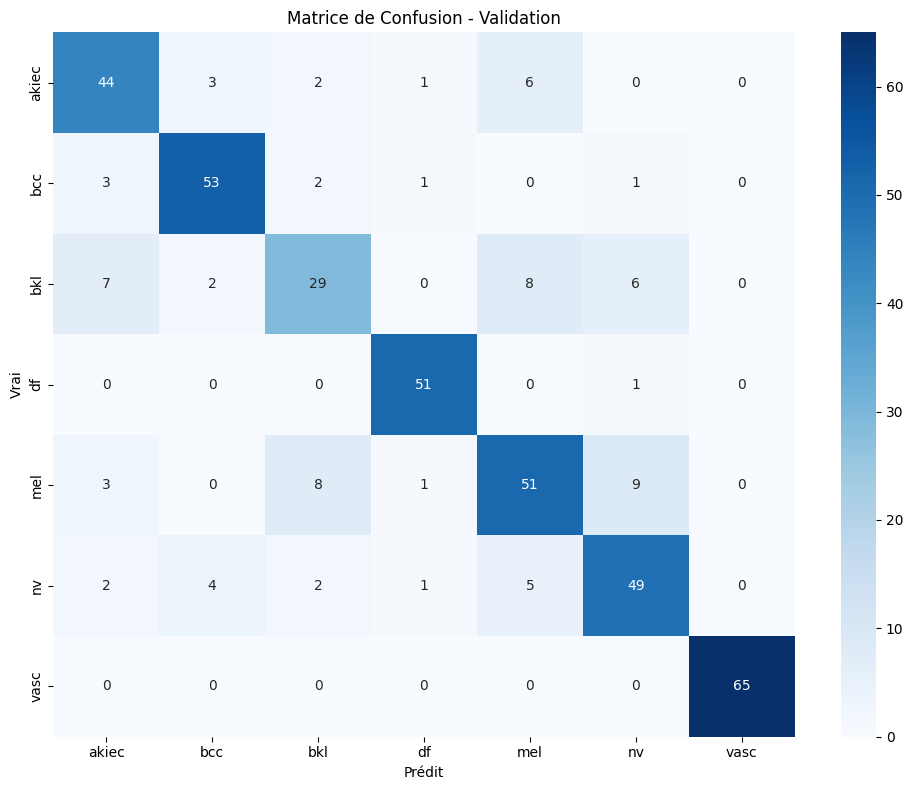


📊 Rapport de classification:
              precision    recall  f1-score   support

       akiec       0.75      0.79      0.77        56
         bcc       0.85      0.88      0.87        60
         bkl       0.67      0.56      0.61        52
          df       0.93      0.98      0.95        52
         mel       0.73      0.71      0.72        72
          nv       0.74      0.78      0.76        63
        vasc       1.00      1.00      1.00        65

    accuracy                           0.81       420
   macro avg       0.81      0.81      0.81       420
weighted avg       0.81      0.81      0.81       420



In [11]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Prédictions sur validation
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        outputs = model(inputs)
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

# Matrice de confusion
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=dataset.classes, 
            yticklabels=dataset.classes)
plt.title('Matrice de Confusion - Validation')
plt.ylabel('Vrai')
plt.xlabel('Prédit')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
mlflow.log_artifact('confusion_matrix.png')
plt.show()

# Rapport de classification
print("\n📊 Rapport de classification:")
print(classification_report(all_labels, all_preds, target_names=dataset.classes))

In [12]:
print("\n" + "="*60)
print("🎯 LIVRABLE 3 - ENTRAÎNEMENT TERMINÉ")
print("="*60)
print(f"""
✅ Meilleure accuracy validation: {best_acc:.2f}%
✅ Modèle sauvegardé: best_model_resnet50.pth
✅ MLflow run: {mlflow.active_run().info.run_id}

🚀 Pour lancer MLflow UI:
   mlflow ui --port 5000

📁 Logs sauvegardés dans: ./mlruns
""")

# Sauvegarde du rapport
with open('classification_report.txt', 'w') as f:
    f.write(classification_report(all_labels, all_preds, target_names=dataset.classes))
mlflow.log_artifact('classification_report.txt')


🎯 LIVRABLE 3 - ENTRAÎNEMENT TERMINÉ

✅ Meilleure accuracy validation: 83.57%
✅ Modèle sauvegardé: best_model_resnet50.pth
✅ MLflow run: 534fd5db603f41eb8e676233b13562d0

🚀 Pour lancer MLflow UI:
   mlflow ui --port 5000

📁 Logs sauvegardés dans: ./mlruns



In [14]:
# Dans VS Code, ouvre un TERMINAL et exécute:
# mlflow ui --port 5000
# Puis ouvre http://localhost:5000 dans ton navigateur

print("""
🔗 Pour voir les résultats MLflow:
1. Ouvre un nouveau terminal
2. Tape: mlflow ui --port 5000
3. Ouvre http://localhost:5000

📊 Tu verras:
   - Toutes les métriques (loss, accuracy)
   - Les hyperparamètres
   - Les modèles sauvegardés
   - Les artefacts (images, rapports)
""")


🔗 Pour voir les résultats MLflow:
1. Ouvre un nouveau terminal
2. Tape: mlflow ui --port 5000
3. Ouvre http://localhost:5000

📊 Tu verras:
   - Toutes les métriques (loss, accuracy)
   - Les hyperparamètres
   - Les modèles sauvegardés
   - Les artefacts (images, rapports)

